In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, RocCurveDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import os
import joblib # Required for saving the preprocessor

In [2]:
try:
    df = pd.read_csv('flight_accidents_india_synthetic.csv')
    print("Dataset loaded successfully. Info:")
    df.info()
    print("\nFirst 5 rows:")
    print(df.head())
except FileNotFoundError:
    print("Error: 'flight_accidents_india_synthetic.csv' not found. Please ensure the file is in the same directory.")
    exit() # Exit if the dataset is not found

Dataset loaded successfully. Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Flight_ID                       2500 non-null   object 
 1   Airline                         2500 non-null   object 
 2   Aircraft_Type                   2500 non-null   object 
 3   Aircraft_Age_Years              2500 non-null   int64  
 4   Flight_Phase                    2500 non-null   object 
 5   Departure_Airport_Code          2500 non-null   object 
 6   Arrival_Airport_Code            2500 non-null   object 
 7   Flight_Duration_Hours           2500 non-null   float64
 8   Last_Maintenance_Hours          2500 non-null   int64  
 9   Engine_Hours_Since_Overhaul     2500 non-null   int64  
 10  Pilot_Experience_Hours          2500 non-null   int64  
 11  CoPilot_Experience_Hours        2500 non-null   int64  
 12 

In [3]:
# --- 2. Prepare Data for Training ---
# Separate target variable 'Accident'
# Exclude identifier columns and other target-related columns that won't be used as features for prediction
X = df.drop(columns=['Accident', 'Accident_Severity', 'Fatalities', 'Injuries', 'Aircraft_Damage', 'Cause_Category', 'Flight_ID', 'Date', 'Time_UTC'])
y = df['Accident']

In [4]:
# Identify numerical and categorical columns for preprocessing
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

In [5]:
print(f"\nNumerical columns identified: {numerical_cols}")
print(f"Categorical columns identified: {categorical_cols}")



Numerical columns identified: ['Aircraft_Age_Years', 'Flight_Duration_Hours', 'Last_Maintenance_Hours', 'Engine_Hours_Since_Overhaul', 'Pilot_Experience_Hours', 'CoPilot_Experience_Hours', 'Number_of_Crew', 'Total_Onboard', 'Cargo_Weight_KG', 'Visibility_KM', 'Wind_Speed_KNOTS', 'Wind_Direction_Degrees', 'Temperature_Celsius', 'Precipitation_MM', 'Departure_Airport_Elevation_FT', 'Arrival_Airport_Elevation_FT']
Categorical columns identified: ['Airline', 'Aircraft_Type', 'Flight_Phase', 'Departure_Airport_Code', 'Arrival_Airport_Code', 'Season', 'Weather_Condition', 'Turbulence_Severity', 'Route_Complexity', 'Air_Traffic_Density']


In [6]:
numerical_transformer = StandardScaler()

# OneHotEncoder for categorical features (handle_unknown='ignore' for unseen categories in new data)
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Fit and transform the training data
# This step applies scaling and one-hot encoding
X_processed = preprocessor.fit_transform(X)

print(f"\nShape of preprocessed data (X_processed): {X_processed.shape}")


Shape of preprocessed data (X_processed): (2500, 81)


In [8]:
# Reshape X_processed for Conv1D input: (samples, timesteps, features)
# For tabular data with Conv1D, each feature is treated as a timestep, and we add a channel dimension of 1.
X_processed = X_processed.reshape(X_processed.shape[0], X_processed.shape[1], 1)

print(f"Reshaped X_processed for Conv1D input: {X_processed.shape}")

Reshaped X_processed for Conv1D input: (2500, 81, 1)


In [9]:
# Split the dataset into training and testing sets
# stratify=y ensures that the proportion of 'Accident' (1s) is the same in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Training data shape: (2000, 81, 1)
Testing data shape: (500, 81, 1)


In [10]:
# --- 4. Define and Compile the CNN Model ---
model = Sequential([
    # First Convolutional Layer
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2), # Reduces dimensionality

    # Second Convolutional Layer
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    # Flatten the output for the Dense layers
    Flatten(),

    # Fully Connected (Dense) Layers
    Dense(128, activation='relu'),
    Dropout(0.5), # Dropout for regularization to prevent overfitting

    # Output layer for binary classification
    Dense(1, activation='sigmoid') # Sigmoid activation for probabilities between 0 and 1
])

# Compile the model
# Adam optimizer is a good default choice
# binary_crossentropy for binary classification problems
# metrics=['accuracy'] to monitor performance during training
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

print("\nCNN Model Summary:")
model.summary()


CNN Model Summary:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 79, 64)            256       
                                                                 
 max_pooling1d (MaxPooling1  (None, 39, 64)            0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 37, 128)           24704     
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 18, 128)           0         
 g1D)                                                            
                                                                 
 flatten (Flatten)           (None, 2304)              0         
                                                                 
 dense (Dense)               (None, 

In [11]:
# --- 5. Train the Model ---
print("\nStarting model training...")
history = model.fit(
    X_train, y_train,
    epochs=50,          # Number of training iterations
    batch_size=32,      # Number of samples per gradient update
    validation_split=0.2, # Use 20% of training data for validation during training
    verbose=1           # Show training progress
)



Starting model training...
Epoch 1/50
50/50 [==============================] - 2s 11ms/step - loss: 0.1363 - accuracy: 0.9737 - val_loss: 0.1206 - val_accuracy: 0.9800
Epoch 2/50
50/50 [==============================] - 0s 7ms/step - loss: 0.0951 - accuracy: 0.9825 - val_loss: 0.1076 - val_accuracy: 0.9800
Epoch 3/50
50/50 [==============================] - 0s 7ms/step - loss: 0.0925 - accuracy: 0.9825 - val_loss: 0.1062 - val_accuracy: 0.9800
Epoch 4/50
50/50 [==============================] - 0s 8ms/step - loss: 0.0911 - accuracy: 0.9825 - val_loss: 0.1157 - val_accuracy: 0.9800
Epoch 5/50
50/50 [==============================] - 0s 7ms/step - loss: 0.0919 - accuracy: 0.9825 - val_loss: 0.1122 - val_accuracy: 0.9800
Epoch 6/50
50/50 [==============================] - 0s 7ms/step - loss: 0.0850 - accuracy: 0.9825 - val_loss: 0.1124 - val_accuracy: 0.9800
Epoch 7/50
50/50 [==============================] - 0s 8ms/step - loss: 0.0802 - accuracy: 0.9825 - val_loss: 0.1161 - val_accuracy

In [12]:
# --- 6. Evaluate the Model ---
print("\nEvaluating the model on the test set...")
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Evaluating the model on the test set...
Test Loss: 0.3337
Test Accuracy: 0.9820


In [13]:
# --- 7. Save the Trained Model and Preprocessor ---
# Save the Keras model in HDF5 format
model_filename = 'flight_accident_cnn_model.h5'
model.save(model_filename)
print(f"\nTrained CNN model saved as '{model_filename}'")


Trained CNN model saved as 'flight_accident_cnn_model.h5'


C:\Users\User\anaconda3\envs\Project\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [14]:
# Save the preprocessor using joblib
# This is crucial because new data must be transformed using the exact same scaling and encoding
preprocessor_filename = 'preprocessor.pkl'
joblib.dump(preprocessor, preprocessor_filename)
print(f"Preprocessor saved as '{preprocessor_filename}'")

print("\nTraining and file creation process complete.")

Preprocessor saved as 'preprocessor.pkl'

Training and file creation process complete.


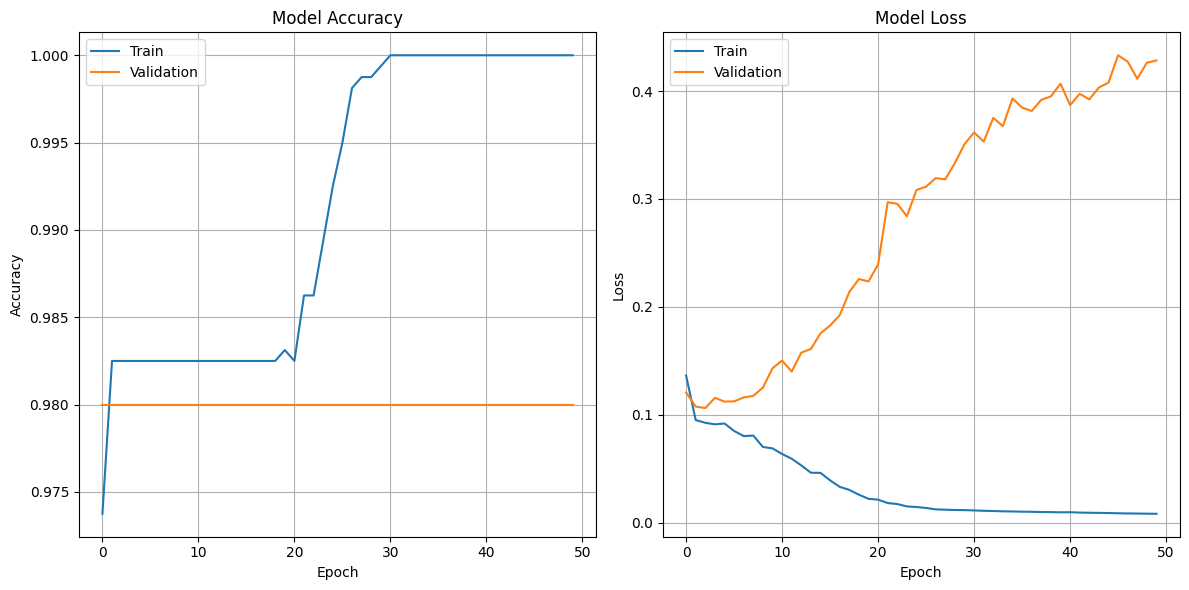

In [15]:
# --- 8. Visualizations ---

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


16/16 [==============================] - 0s 2ms/step


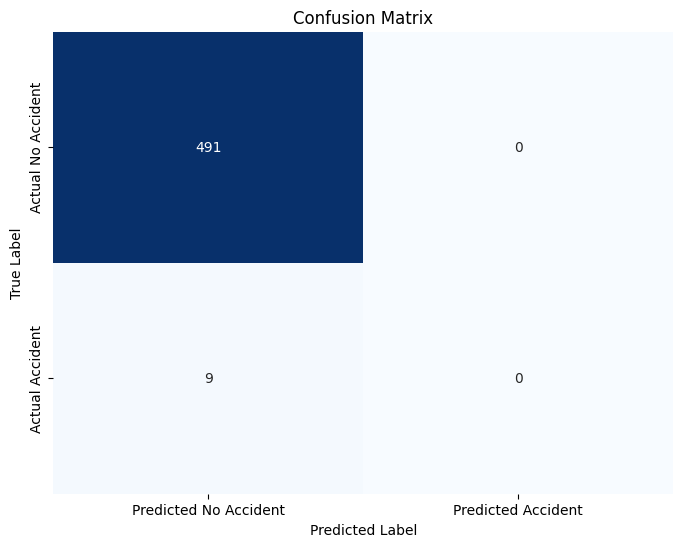

In [16]:
y_pred_proba = model.predict(X_test)
# Convert probabilities to binary predictions (0 or 1)
y_pred = (y_pred_proba > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Accident', 'Predicted Accident'],
            yticklabels=['Actual No Accident', 'Actual Accident'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [17]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       491
           1       0.00      0.00      0.00         9

    accuracy                           0.98       500
   macro avg       0.49      0.50      0.50       500
weighted avg       0.96      0.98      0.97       500



C:\Users\User\anaconda3\envs\Project\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\User\anaconda3\envs\Project\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\User\anaconda3\envs\Project\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


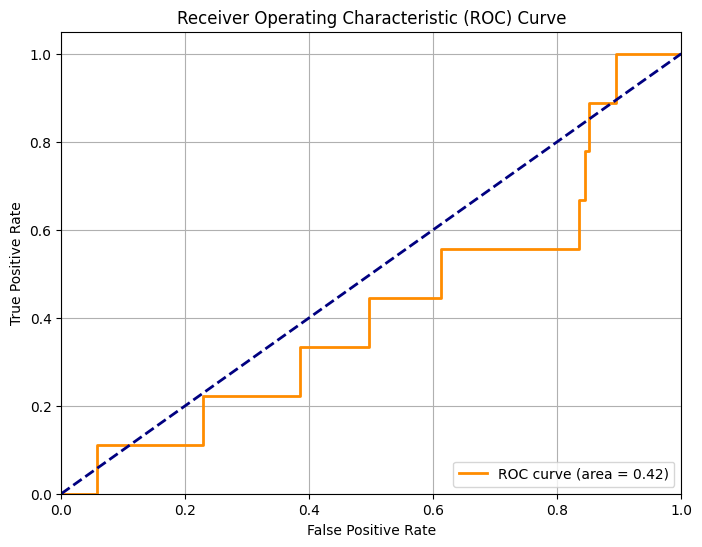

In [18]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [19]:
# Scatter Chart for two numerical features, colored by target
# Using original features before preprocessing for better interpretability
# Check if these columns exist in the original DataFrame
if 'Aircraft_Age_Years' in df.columns and 'Flight_Hours_Last_Service' in df.columns:
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x='Aircraft_Age_Years', y='Flight_Hours_Last_Service', hue='Accident', data=df, palette='viridis', alpha=0.7)
    plt.title('Aircraft Age vs. Flight Hours Last Service by Accident Status')
    plt.xlabel('Aircraft Age (Years)')
    plt.ylabel('Flight Hours Since Last Service')
    plt.grid(True)
    plt.show()
else:
    print("\n'Aircraft_Age_Years' or 'Flight_Hours_Last_Service' not found for scatter plot.")

# Feature Bar Charts for categorical features
# Using original features before preprocessing
plt.figure(figsize=(15, 6))


'Aircraft_Age_Years' or 'Flight_Hours_Last_Service' not found for scatter plot.


<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>


'Phase_of_Flight' column not found for bar chart.


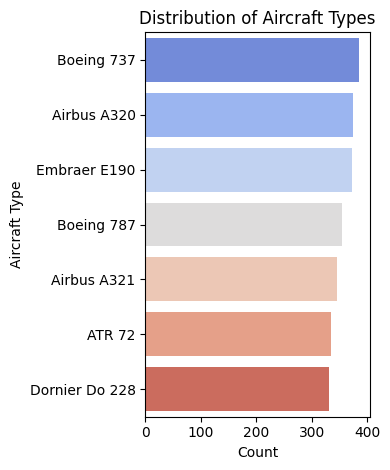

In [20]:
if 'Aircraft_Type' in df.columns:
    plt.subplot(1, 2, 1)
    sns.countplot(y='Aircraft_Type', data=df, order=df['Aircraft_Type'].value_counts().index, palette='coolwarm')
    plt.title('Distribution of Aircraft Types')
    plt.xlabel('Count')
    plt.ylabel('Aircraft Type')
else:
    print("\n'Aircraft_Type' column not found for bar chart.")

if 'Phase_of_Flight' in df.columns:
    plt.subplot(1, 2, 2)
    sns.countplot(y='Phase_of_Flight', data=df, order=df['Phase_of_Flight'].value_counts().index, palette='viridis')
    plt.title('Distribution of Phase of Flight')
    plt.xlabel('Count')
    plt.ylabel('Phase of Flight')
else:
    print("\n'Phase_of_Flight' column not found for bar chart.")

plt.tight_layout()
plt.show()
